## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    GRU,
    Conv1D,
    MaxPooling1D
)

from tensorflow.keras.callbacks import EarlyStopping


I0000 00:00:1778681530.575848   59161 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1778681530.576873   59161 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778681530.620064   59161 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778681531.822194   59161 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

## Prepare data

In [2]:
import numpy as np
import pandas as pd

# Load data
DATA_PATH = "/home/student25/Documents/THESIS/MSC_THESIS_package_corrected - Revised/SPATIO-TEMPORAL THESIS/DATA/train_data.csv"

df = pd.read_csv(DATA_PATH)

print(df.head())

    county        date   rainfall  temperature   humidity      ndvi  \
0  Nairobi  2016-01-01  49.275605    25.637804  61.742508  0.733088   
1  Nairobi  2016-02-01  73.528041    23.151834  72.958351  0.445615   
2  Nairobi  2016-03-01  47.764552    25.751396  88.466566  0.782816   
3  Nairobi  2016-04-01  92.370033    25.778698  69.351332  0.560034   
4  Nairobi  2016-05-01  99.289476    24.397793  68.140471  0.714369   

     population       itn       irs  treatment  cases  incidence_per_1000  
0  4.120841e+06  0.640446  0.383229   0.508234      8            0.001941  
1  4.128487e+06  0.644741  0.155798   0.616858      6            0.001453  
2  4.136147e+06  0.723359  0.221846   0.539069      4            0.000967  
3  4.143822e+06  0.618684  0.173942   0.887834      6            0.001448  
4  4.151511e+06  0.542701  0.212374   0.717078     13            0.003131  



### DATE FEATURES


In [3]:

df["date"] = pd.to_datetime(df["date"])

df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year


## CONTY AND MONTHLY ENCODING for seasonal continuity .


In [4]:

# MONTHLY ENCODING

df["sin_m"] = np.sin(2 * np.pi * df["month"] / 12)

df["cos_m"] = np.cos(2 * np.pi * df["month"] / 12)



# COUNTY ENCODING


counties = sorted(df["county"].unique())

county_map = {}

for i, county in enumerate(counties):

    county_map[county] = i

df["county_enc"] = df["county"].map(county_map)




## SORT DATA AND CREATING LAG FEATURES


In [5]:

 # SORTING THE DATA since Temporal models depend on correct chronological order.
    
df = df.sort_values(["county", "date"])



# LAG FEATURES and  grouping per county to ensures malaria history is calculated separately for each count


for lag in [1, 2, 3, 6, 12]:

    df[f"lag_{lag}"] = (
        df.groupby("county")["incidence_per_1000"]
        .shift(lag)
    )


### Lagged malaria incidence variables were generated at 1-, 2-, 3-, 6-, and 12-month intervals to capture short term and seasonal temporal dependencies in malaria transmission dynamics


### ROLLING FEATURES


In [6]:


for win in [3, 6, 12]:

    df[f"roll{win}_mean"] = (
        df.groupby("county")["incidence_per_1000"]
        .transform(lambda x: x.shift(1).rolling(win).mean())
    )

    df[f"roll{win}_std"] = (
        df.groupby("county")["incidence_per_1000"]
        .transform(lambda x: x.shift(1).rolling(win).std())
    )


### Rolling statistical features including moving averages and standard deviations over 3-, 6-, and 12-month windows were generated to capture temporal malaria trends, seasonal patterns, and transmission variability.

In [7]:

# INTERACTION FEATURES


df["rain_temp"] = df["rainfall"] * df["temperature"]

df["rain_ndvi"] = df["rainfall"] * df["ndvi"]

df["itn_irs"] = df["itn"] * df["irs"]

df["hum_temp"] = df["humidity"] * df["temperature"]


df = df.dropna()


### TRAIN TEST SPLIT


In [8]:


train_df = df[df["date"] < "2023-01-01"]

test_df = df[df["date"] >= "2023-01-01"]




### FEATURES



In [9]:
#FEATURE DEFINIING , THE PREDICTOR VARIABLES
FEATS = [

    "rainfall",
    "temperature",
    "humidity",
    "ndvi",
    "population",
    "itn",
    "irs",
    "treatment",

    "sin_m",
    "cos_m",

    "year",
    "county_enc",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_6",
    "lag_12",

    "roll3_mean",
    "roll6_mean",
    "roll12_mean",

    "roll3_std",
    "roll6_std",
    "roll12_std",

    "rain_temp",
    "rain_ndvi",
    "itn_irs",
    "hum_temp"
]

TARGET = "incidence_per_1000"



### SCALING DATA


(3384, 27, 1)
(564, 27, 1)
Epoch 1/150


E0000 00:00:1778681532.298990   59161 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/student25/student25/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.0517e-04 - val_loss: 1.1717e-04
Epoch 2/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6394e-04 - val_loss: 1.0888e-04
Epoch 3/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5883e-04 - val_loss: 1.0523e-04
Epoch 4/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.6158e-04 - val_loss: 1.0178e-04
Epoch 5/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5844e-04 - val_loss: 9.9521e-05
Epoch 6/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.5455e-04 - val_loss: 1.0152e-04
Epoch 7/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4919e-04 - val_loss: 1.0334e-04
Epoch 8/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.4083e-04 - val_loss: 9.6456e-05
Epoch 9/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3062e-04 - val_loss: 9.1915e-05
Epoch 10/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.3751e-04 - val_loss: 9.9141e-05
Epoch 11/150
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2.2750e-04 - val_loss

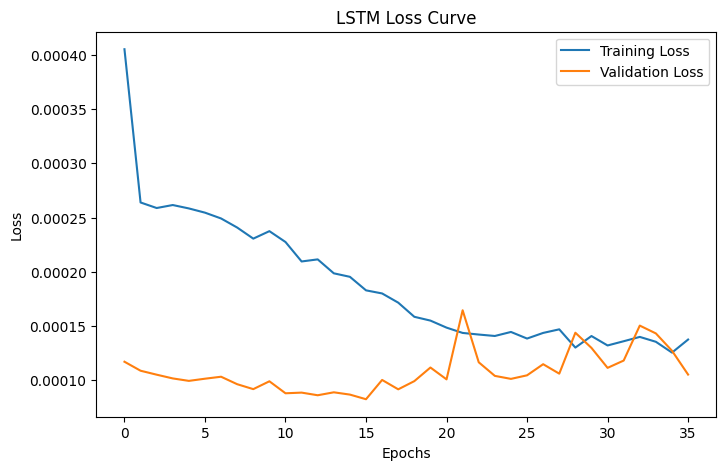

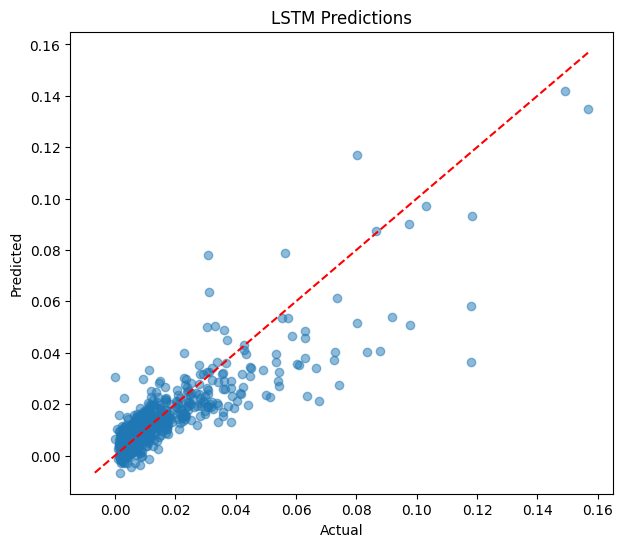

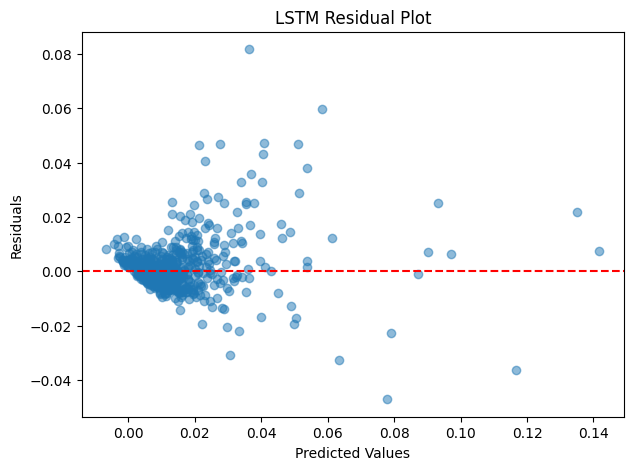

In [10]:


sx = MinMaxScaler()

Xtr = sx.fit_transform(train_df[FEATS])

Xte = sx.transform(test_df[FEATS])

ytr = train_df[TARGET].values

yte = test_df[TARGET].values


# RESHAPE FOR TENSORFLOW


Xtr_dl = Xtr.reshape(
    Xtr.shape[0],
    Xtr.shape[1],
    1
)

Xte_dl = Xte.reshape(
    Xte.shape[0],
    Xte.shape[1],
    1
)

print(Xtr_dl.shape)
print(Xte_dl.shape)



# EVALUATION FUNCTION


def evaluate_model(name, y_true, y_pred):

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("\n", name)

    print("RMSE:", round(rmse, 5))

    print("MAE :", round(mae, 5))

    print("R2  :", round(r2, 4))

    return rmse, mae, r2



# TRUE LSTM MODEL


lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        input_shape=(Xtr_dl.shape[1], 1)
    )
)

lstm_model.add(
    Dense(32, activation="relu")
)

lstm_model.add(
    Dense(1)
)

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)



# EARLY STOPPING


early_stop = EarlyStopping(
    patience=20,
    restore_best_weights=True
)



# TRAIN MODEL


history = lstm_model.fit(

    Xtr_dl,
    ytr,

    validation_split=0.1,

    epochs=150,

    batch_size=32,

    callbacks=[early_stop],

    verbose=1
)



# PREDICTIONS


lstm_pred = (
    lstm_model.predict(Xte_dl)
    .flatten()
)




# EVALUATION


lstm_rmse, lstm_mae, lstm_r2 = evaluate_model(
    "LSTM Model",
    yte,
    lstm_pred
)


# LOSS CURVE


plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("LSTM Loss Curve")

plt.legend()

plt.show()



# PREDICTED VS ACTUAL


plt.figure(figsize=(7, 6))

plt.scatter(
    yte,
    lstm_pred,
    alpha=0.5
)

mn = min(yte.min(), lstm_pred.min())

mx = max(yte.max(), lstm_pred.max())

plt.plot(
    [mn, mx],
    [mn, mx],
    "r--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("LSTM Predictions")

plt.show()


# RESIDUAL PLOT


residuals = yte - lstm_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    lstm_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("LSTM Residual Plot")

plt.show()

### CNN-LSTM MODEL

In [11]:

# CNN-LSTM MODEL


from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    LSTM,
    GRU,
    Conv1D,
    MaxPooling1D,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# Improved CNN-LSTM

cnn_lstm = Sequential()

# CNN Layer
cnn_lstm.add(
    Conv1D(
        filters=128,
        kernel_size=2,
        activation="relu",
        input_shape=(Xtr_dl.shape[1], 1)
    )
)

cnn_lstm.add(
    MaxPooling1D(pool_size=2)
)

cnn_lstm.add(
    BatchNormalization()
)

# First LSTM
cnn_lstm.add(
    LSTM(
        128,
        return_sequences=True
    )
)

cnn_lstm.add(
    Dropout(0.2)
)

# Second LSTM
cnn_lstm.add(
    LSTM(64)
)

cnn_lstm.add(
    Dropout(0.2)
)

# Dense Layers
cnn_lstm.add(
    Dense(32, activation="relu")
)

cnn_lstm.add(
    Dense(16, activation="relu")
)

cnn_lstm.add(
    Dense(1)
)
# Compile
cnn_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Callbacks
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    verbose=1
)

# Train
history_cnn_lstm = cnn_lstm.fit(

    Xtr_dl,
    ytr,

    validation_split=0.1,

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)

# Predictions
cnn_lstm_pred = (
    cnn_lstm.predict(Xte_dl)
    .flatten()
)

# Metrics
cnn_lstm_rmse = np.sqrt(
    mean_squared_error(yte, cnn_lstm_pred)
)

cnn_lstm_mae = mean_absolute_error(
    yte,
    cnn_lstm_pred
)

cnn_lstm_r2 = r2_score(
    yte,
    cnn_lstm_pred
)

print("\nCNN-LSTM Results")

print("RMSE:", round(cnn_lstm_rmse, 5))

print("MAE :", round(cnn_lstm_mae, 5))

print("R2  :", round(cnn_lstm_r2, 4))

Epoch 1/200


/home/student25/student25/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 8.0610e-04 - mae: 0.0151 - val_loss: 3.4780e-04 - val_mae: 0.0166 - learning_rate: 0.0010
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.5607e-04 - mae: 0.0112 - val_loss: 4.1571e-04 - val_mae: 0.0187 - learning_rate: 0.0010
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.9584e-04 - mae: 0.0098 - val_loss: 3.6505e-04 - val_mae: 0.0174 - learning_rate: 0.0010
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.5911e-04 - mae: 0.0093 - val_loss: 2.3518e-04 - val_mae: 0.0135 - learning_rate: 0.0010
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4610e-04 - mae: 0.0089 - val_loss: 1.3873e-04 - val_mae: 0.0098 - learning_rate: 0.0010
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2250e-04 - mae: 0.0084 - val_loss: 1.1995e-04 - val_mae: 0.0074 - learning_rate: 0.0010
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.1529e-04 - mae: 0.0083 - val_loss: 1.0753e-04 - val_mae:

Epoch 82/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.3891e-05 - mae: 0.0050 - val_loss: 6.1725e-05 - val_mae: 0.0051 - learning_rate: 7.8125e-06
Epoch 83/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.4790e-05 - mae: 0.0051 - val_loss: 5.9991e-05 - val_mae: 0.0051 - learning_rate: 7.8125e-06
Epoch 84/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.0209e-05 - mae: 0.0050 - val_loss: 6.0936e-05 - val_mae: 0.0051 - learning_rate: 7.8125e-06
Epoch 85/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.5018e-05 - mae: 0.0052 - val_loss: 6.1548e-05 - val_mae: 0.0051 - learning_rate: 7.8125e-06
Epoch 86/200
92/96 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 5.7474e-05 - mae: 0.0052
Epoch 86: ReduceLROnPlateau reducing learning rate to 3.906250185536919e-06.
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 5.4614e-05 - mae: 0.0051 - val_loss: 6.0415e-05 - val_mae: 0.0051 - learning_rate: 7.8125e-06
Epoch 87/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 5.0448e-05 - mae: 0.0

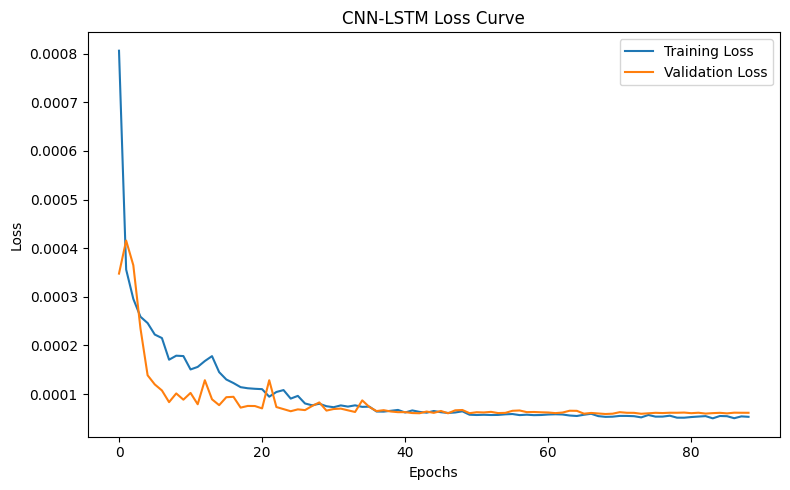

In [12]:

# CNN-LSTM LOSS CURVE


plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn_lstm.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn_lstm.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("CNN-LSTM Loss Curve")

plt.legend()

plt.tight_layout()
plt.savefig("CNN-LSTM Loss Curve.png", bbox_inches='tight')
plt.show()


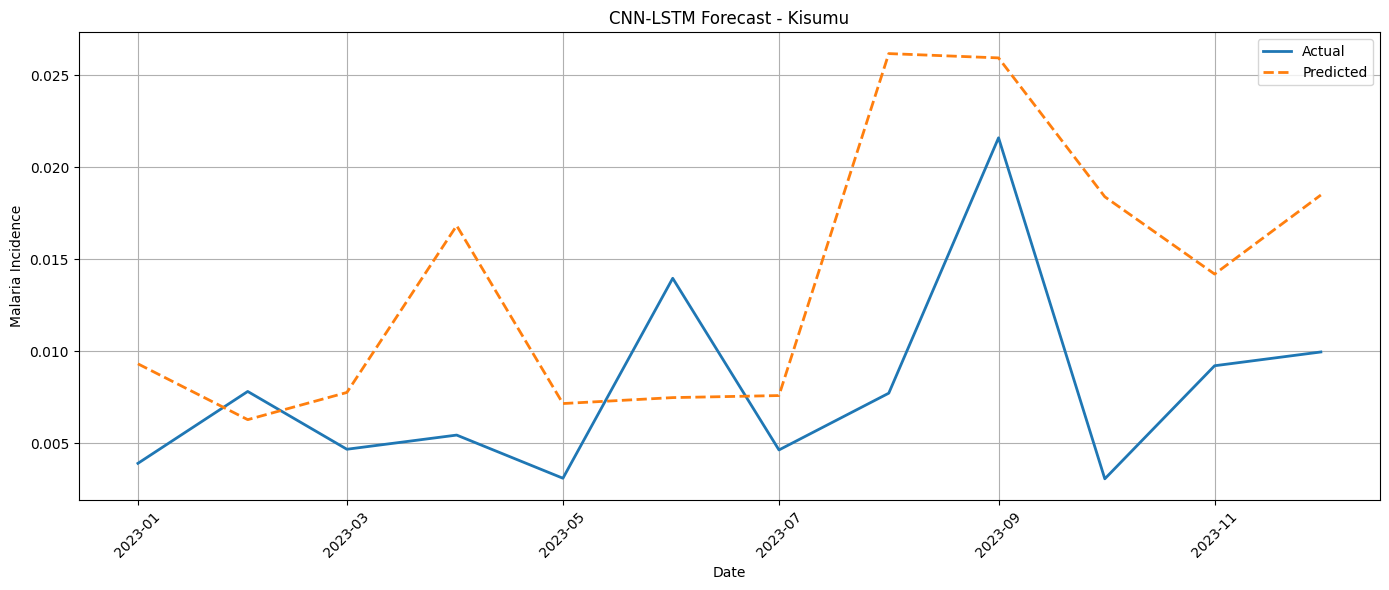

In [13]:

# CNN-LSTM TIME SERIES


county_name = "Kisumu"

county_data = test_df[
    test_df["county"] == county_name
].copy()

county_data = county_data.sort_values("date")

actual = county_data["incidence_per_1000"].values

predicted = cnn_lstm_pred[county_data.index]

dates = county_data["date"]

plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates,
    predicted,
    linestyle="--",
    label="Predicted",
    linewidth=2
)

plt.xlabel("Date")

plt.ylabel("Malaria Incidence")

plt.title(f"CNN-LSTM Forecast - {county_name}")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

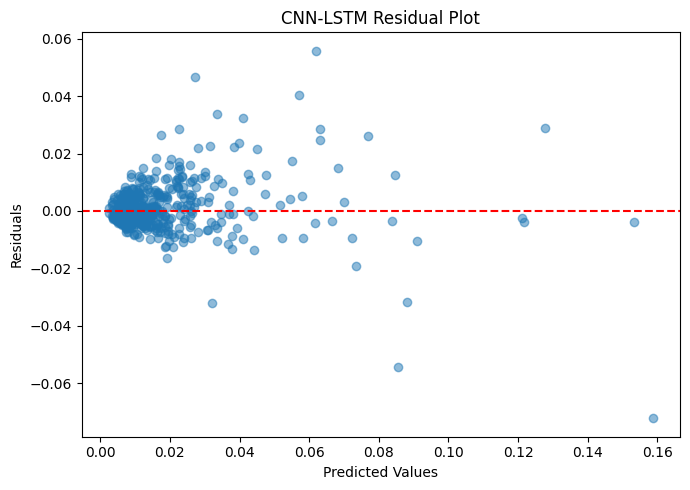

In [14]:

# CNN-LSTM RESIDUAL PLOT


residuals = yte - cnn_lstm_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    cnn_lstm_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("CNN-LSTM Residual Plot")

plt.tight_layout()

plt.show()

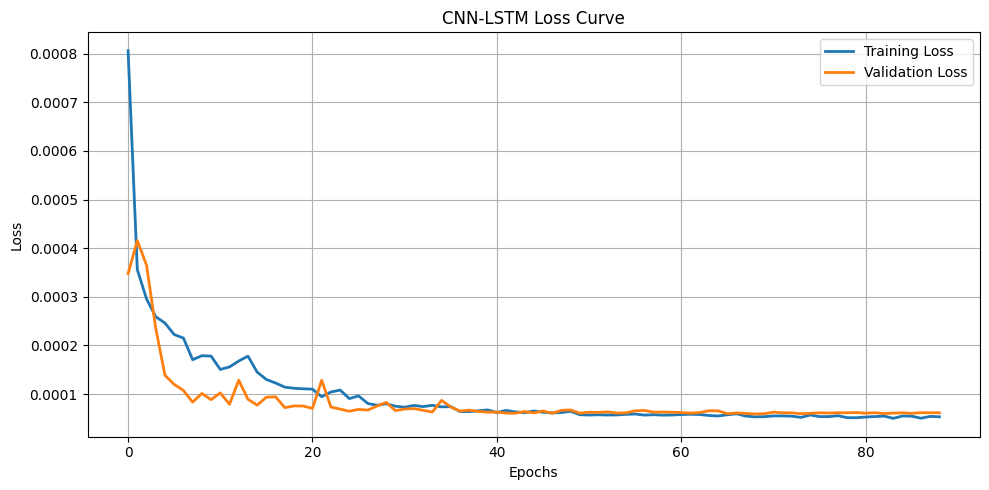

In [15]:
# CNN-LSTM LOSS CURVE

plt.figure(figsize=(10,5))

plt.plot(
    history_cnn_lstm.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history_cnn_lstm.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.title("CNN-LSTM Loss Curve")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.tight_layout()
plt.savefig("CNN-LSTM Loss Curve.png", bbox_inches='tight')
plt.show()


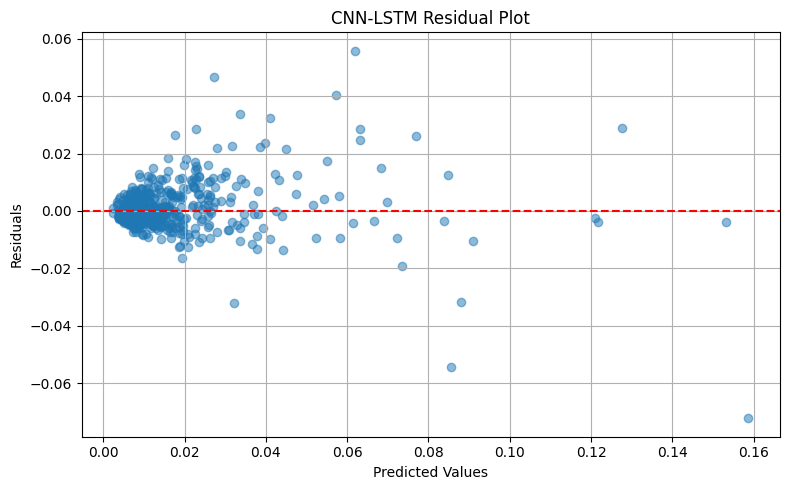

In [16]:
# CNN-LSTM RESIDUAL PLOT

residuals = yte - cnn_lstm_pred

plt.figure(figsize=(8,5))

plt.scatter(
    cnn_lstm_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("CNN-LSTM Residual Plot")

plt.grid(True)

plt.tight_layout()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


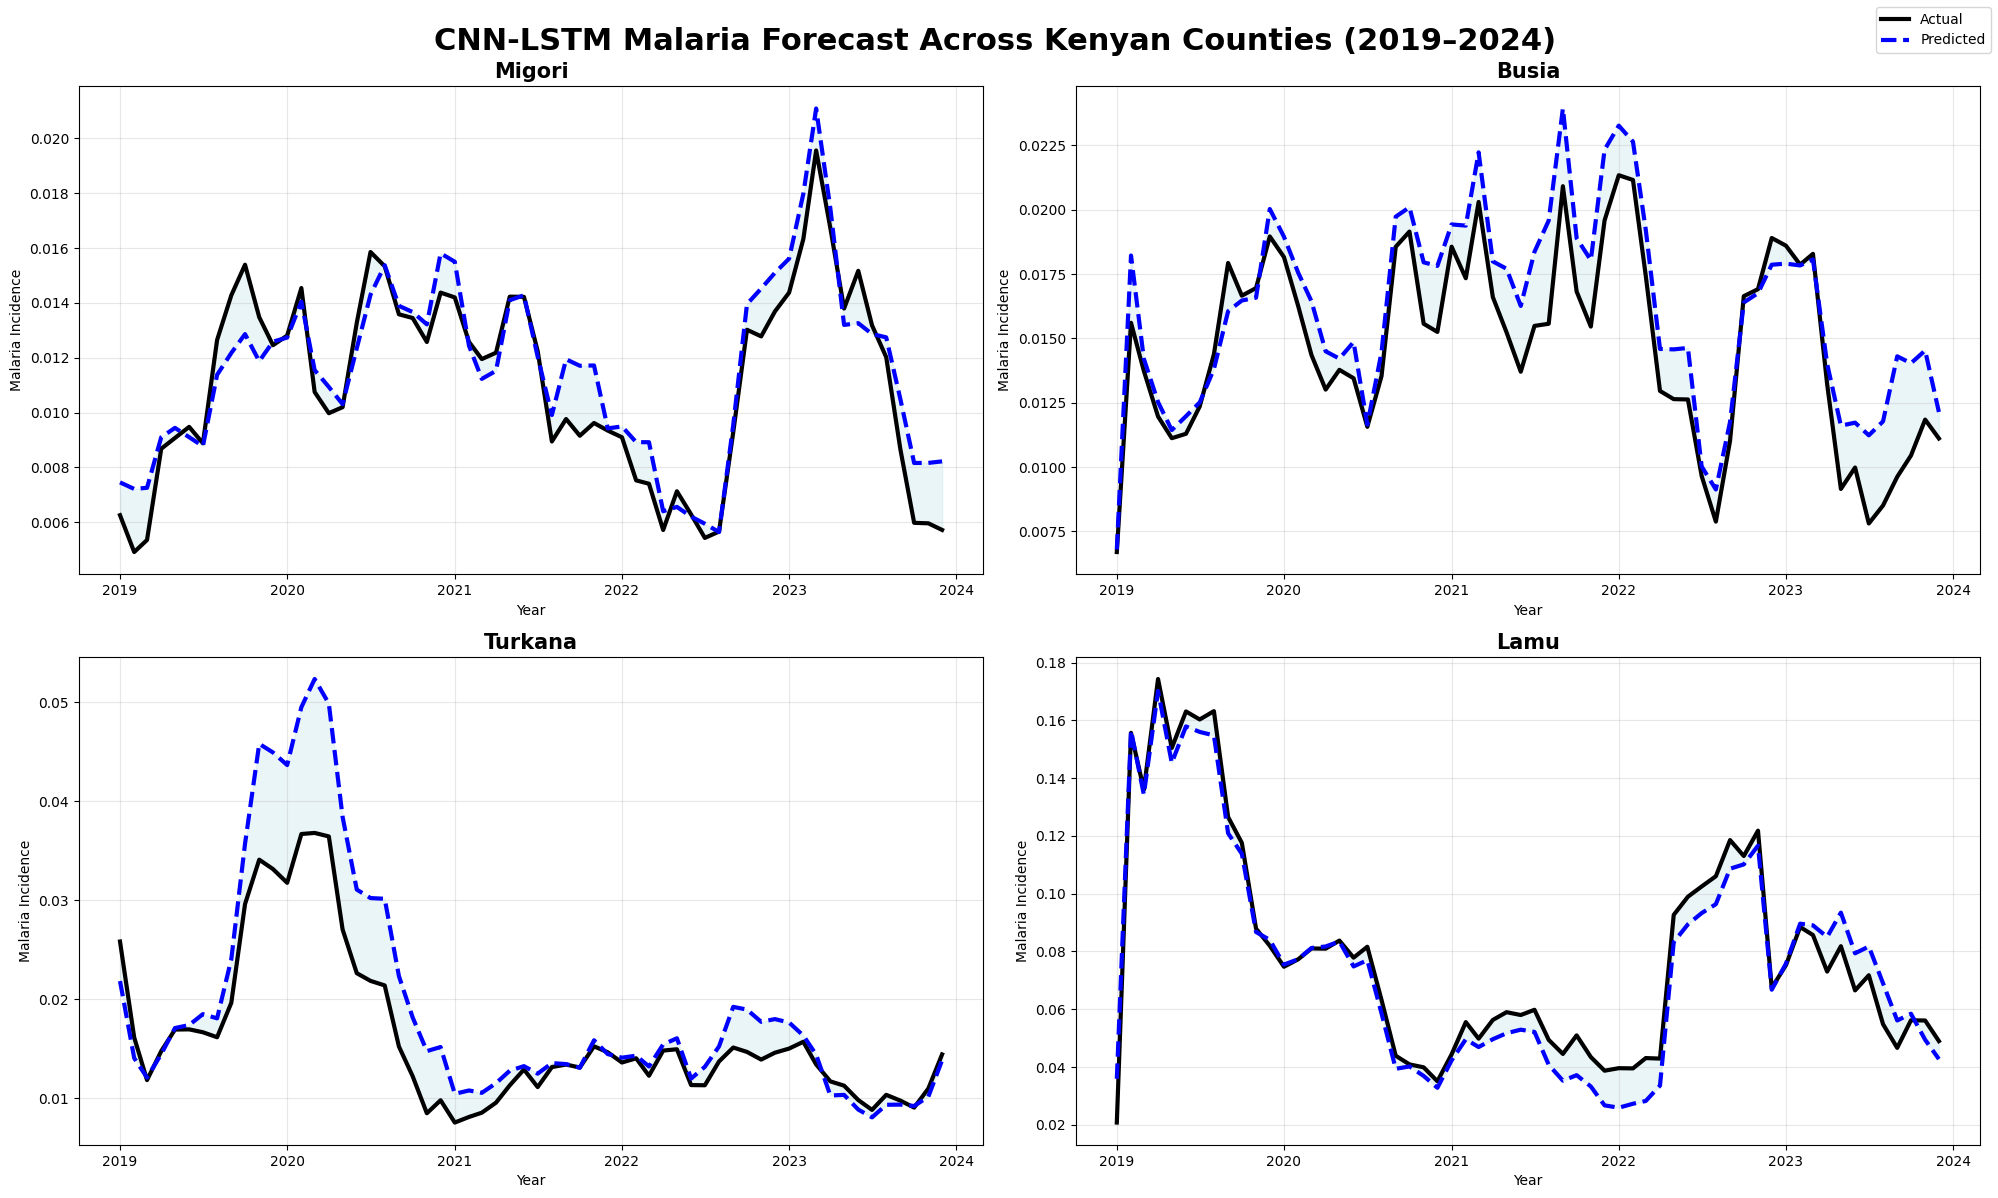

In [17]:

# FINAL 5-YEAR CNN-LSTM FORECAST PLOTS

#specific hotspot counties trends

counties_to_plot = [
    "Migori",
    "Busia",
    "Turkana",
    "Lamu"
]


# FIGURE


fig, axes = plt.subplots(
    2,
    2,
    figsize=(20, 12)
)

axes = axes.flatten()


# LOOP THROUGH COUNTIES


for i, county_name in enumerate(counties_to_plot):

    
    # FILTER COUNTY DATA


    county_data = df[
        (df["county"] == county_name) &
        (df["date"] >= "2019-01-01")
    ].copy()

    county_data = county_data.sort_values("date")

   
    # FEATURES
    X_county = sx.transform(
        county_data[FEATS]
    )

    
    # RESHAPING

    X_county_dl = X_county.reshape(
        X_county.shape[0],
        X_county.shape[1],
        1
    )


    # PREDICTIONS
    

    predicted = (
        cnn_lstm.predict(X_county_dl)
        .flatten()
    )

    # ACTUAL VALUES

    actual = county_data[
        "incidence_per_1000"
    ].values

    dates = pd.to_datetime(
        county_data["date"]
    )

    
    # MODERATE SMOOTHING
    

    actual_smooth = (
        pd.Series(actual)
        .interpolate(method="linear")
        .rolling(7, min_periods=1)
        .mean()
    )

    predicted_smooth = (
        pd.Series(predicted)
        .interpolate(method="linear")
        .rolling(7, min_periods=1)
        .mean()
    )

   
    # ACTUAL
    

    axes[i].plot(
        dates,
        actual_smooth,
        color="black",
        linewidth=3,
        label="Actual"
    )

    
    # PREDICTED
   

    axes[i].plot(
        dates,
        predicted_smooth,
        color="blue",
        linestyle="--",
        linewidth=3,
        label="Predicted"
    )

    # SHADED ERROR
    

    axes[i].fill_between(
        dates,
        actual_smooth,
        predicted_smooth,
        color="lightblue",
        alpha=0.25
    )

    # TITLES
    

    axes[i].set_title(
        county_name,
        fontsize=15,
        fontweight="bold"
    )

    axes[i].set_xlabel("Year")

    axes[i].set_ylabel(
        "Malaria Incidence"
    )

    axes[i].grid(
        True,
        alpha=0.3
    )


# MAIN TITLE


fig.suptitle(
    "CNN-LSTM Malaria Forecast Across Kenyan Counties (2019–2024)",
    fontsize=22,
    fontweight="bold"
)


# LEGEND


handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper right"
)


# LAYOUT


plt.tight_layout()
plt.savefig("CNN-LSTM Malaria Forecast Across Kenyan Counties (2019–2024).png", bbox_inches='tight')
plt.show()


### CNN-GRU MODEL

In [40]:

# CNN-GRU MODEL

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    GRU,
    Conv1D,
    MaxPooling1D,
    Dropout,
    BatchNormalization
)

# Build model
cnn_gru = Sequential()

# CNN Layer
cnn_gru.add(
    Conv1D(
        filters=128,
        kernel_size=2,
        activation="relu",
        input_shape=(Xtr_dl.shape[1], 1)
    )
)

cnn_gru.add(
    MaxPooling1D(pool_size=2)
)

cnn_gru.add(
    BatchNormalization()
)

# First GRU Layer
cnn_gru.add(
    GRU(
        128,
        return_sequences=True
    )
)

cnn_gru.add(
    Dropout(0.2)
)

# Second GRU Layer
cnn_gru.add(
    GRU(64)
)

cnn_gru.add(
    Dropout(0.2)
)

# Dense Layers
cnn_gru.add(
    Dense(32, activation="relu")
)

cnn_gru.add(
    Dense(16, activation="relu")
)

cnn_gru.add(
    Dense(1)
)

# Compile
cnn_gru.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# CALLBACKS


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    verbose=1
)

# TRAIN MODEL

history_cnn_gru = cnn_gru.fit(

    Xtr_dl,
    ytr,

    validation_split=0.1,

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)


# PREDICTIONS


cnn_gru_pred = (
    cnn_gru.predict(Xte_dl)
    .flatten()
)


# EVALUATION


cnn_gru_rmse = np.sqrt(
    mean_squared_error(yte, cnn_gru_pred)
)

cnn_gru_mae = mean_absolute_error(
    yte,
    cnn_gru_pred
)

cnn_gru_r2 = r2_score(
    yte,
    cnn_gru_pred
)

print("\nCNN-GRU Results")

print("RMSE:", round(cnn_gru_rmse, 5))

print("MAE :", round(cnn_gru_mae, 5))

print("R2  :", round(cnn_gru_r2, 4))

Epoch 1/200


/home/student25/student25/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 9.1427e-04 - mae: 0.0161 - val_loss: 4.1394e-04 - val_mae: 0.0187 - learning_rate: 0.0010
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 3.3629e-04 - mae: 0.0101 - val_loss: 4.4350e-04 - val_mae: 0.0195 - learning_rate: 0.0010
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.7942e-04 - mae: 0.0093 - val_loss: 5.7789e-04 - val_mae: 0.0227 - learning_rate: 0.0010
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.4687e-04 - mae: 0.0090 - val_loss: 2.9191e-04 - val_mae: 0.0156 - learning_rate: 0.0010
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.2001e-04 - mae: 0.0085 - val_loss: 2.6091e-04 - val_mae: 0.0146 - learning_rate: 0.0010
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 2.0639e-04 - mae: 0.0081 - val_loss: 1.8356e-04 - val_mae: 0.0117 - learning_rate: 0.0010
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.9149e-04 - mae: 0.0079 - val_loss: 9.1061e-05 - val_mae:

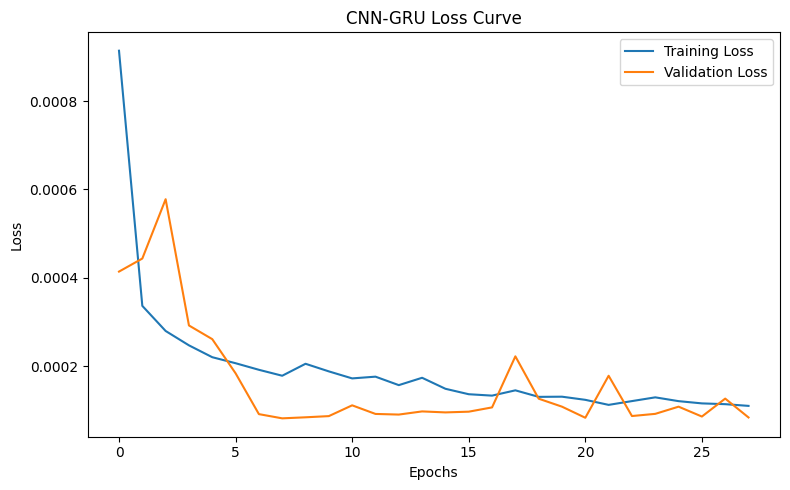

In [41]:

# CNN-GRU LOSS CURVE


plt.figure(figsize=(8, 5))

plt.plot(
    history_cnn_gru.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_cnn_gru.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("CNN-GRU Loss Curve")

plt.legend()

plt.tight_layout()

plt.show()

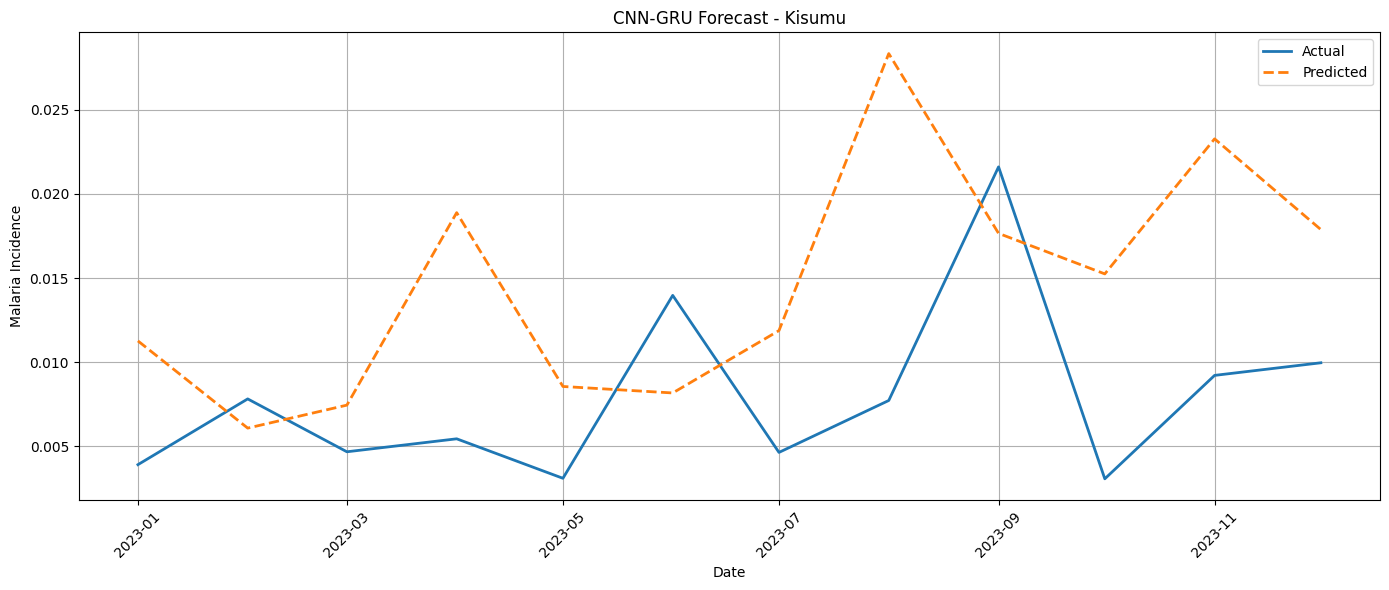

In [42]:

# CNN-GRU TIME SERIES PLOT


county_name = "Kisumu"

county_data = test_df[
    test_df["county"] == county_name
].copy()

county_data = county_data.sort_values("date")

actual = county_data["incidence_per_1000"].values

predicted = cnn_gru_pred[county_data.index]

dates = county_data["date"]

plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates,
    predicted,
    linestyle="--",
    label="Predicted",
    linewidth=2
)

plt.xlabel("Date")

plt.ylabel("Malaria Incidence")

plt.title(f"CNN-GRU Forecast - {county_name}")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

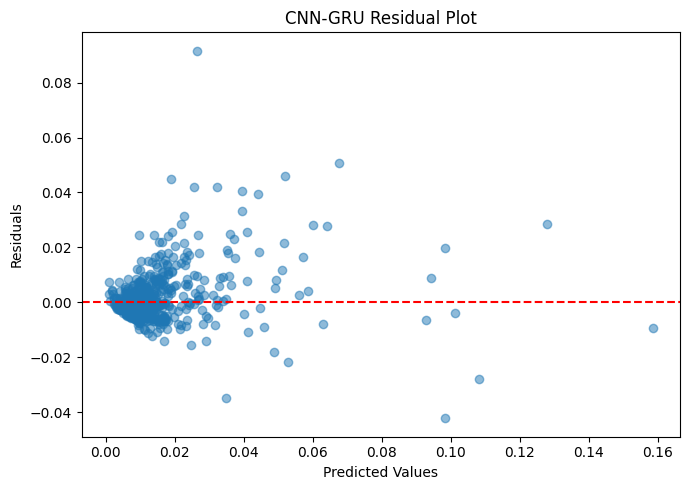

In [43]:

# CNN-GRU RESIDUAL PLOT
residuals = yte - cnn_gru_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    cnn_gru_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("CNN-GRU Residual Plot")

plt.tight_layout()

plt.show()

### CNN-TRANSFOMER MODEL

In [44]:

# CNN-TRANSFORMER MODEL


from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Conv1D,
    MaxPooling1D,
    Dropout,
    BatchNormalization,
    MultiHeadAttention,
    LayerNormalization,
    GlobalAveragePooling1D,
    Input
)

from tensorflow.keras.models import Model

from tensorflow.keras.optimizers import Adam


# INPUT LAYER


inputs = Input(
    shape=(Xtr_dl.shape[1], 1)
)


# CNN LAYER


x = Conv1D(
    filters=128,
    kernel_size=2,
    activation="relu"
)(inputs)

x = MaxPooling1D(pool_size=2)(x)

x = BatchNormalization()(x)


# TRANSFORMER BLOCK


attention = MultiHeadAttention(
    num_heads=4,
    key_dim=32
)(x, x)

x = LayerNormalization()(x + attention)


# GLOBAL POOLING


x = GlobalAveragePooling1D()(x)


# DENSE LAYERS


x = Dense(
    64,
    activation="relu"
)(x)

x = Dropout(0.2)(x)

x = Dense(
    32,
    activation="relu"
)(x)

outputs = Dense(1)(x)

# BUILD MODEL


cnn_transformer = Model(
    inputs,
    outputs
)


# COMPILE


cnn_transformer.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)


# CALLBACKS


early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    verbose=1
)

# TRAIN MODEL


history_transformer = cnn_transformer.fit(

    Xtr_dl,
    ytr,

    validation_split=0.1,

    epochs=200,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr
    ],

    verbose=1
)


# PREDICTIONS


transformer_pred = (
    cnn_transformer.predict(Xte_dl)
    .flatten()
)


# EVALUATION


transformer_rmse = np.sqrt(
    mean_squared_error(yte, transformer_pred)
)

transformer_mae = mean_absolute_error(
    yte,
    transformer_pred
)

transformer_r2 = r2_score(
    yte,
    transformer_pred
)

print("\nCNN-Transformer Results")

print("RMSE:", round(transformer_rmse, 5))

print("MAE :", round(transformer_mae, 5))

print("R2  :", round(transformer_r2, 4))

Epoch 1/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0046 - mae: 0.0423 - val_loss: 0.0236 - val_mae: 0.1497 - learning_rate: 0.0010
Epoch 2/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0011 - mae: 0.0201 - val_loss: 7.4819e-04 - val_mae: 0.0215 - learning_rate: 0.0010
Epoch 3/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.9069e-04 - mae: 0.0132 - val_loss: 1.6935e-04 - val_mae: 0.0096 - learning_rate: 0.0010
Epoch 4/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.9198e-04 - mae: 0.0121 - val_loss: 1.8439e-04 - val_mae: 0.0106 - learning_rate: 0.0010
Epoch 5/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.9933e-04 - mae: 0.0117 - val_loss: 2.1216e-04 - val_mae: 0.0106 - learning_rate: 0.0010
Epoch 6/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4.0199e-04 - mae: 0.0118 - val_loss: 1.7565e-04 - val_mae: 0.0101 - learning_rate: 0.0010
Epoch 7/200
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3.4747e-04 - mae: 0.0113 - val_loss: 1.7682e-04 - val_mae: 

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.1992e-04 - mae: 0.0092 - val_loss: 1.4199e-04 - val_mae: 0.0085 - learning_rate: 1.2500e-04
Epoch 43/200
84/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2714e-04 - mae: 0.0093
Epoch 43: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.4277e-04 - mae: 0.0093 - val_loss: 1.5727e-04 - val_mae: 0.0089 - learning_rate: 1.2500e-04
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

CNN-Transformer Results
RMSE: 0.01447
MAE : 0.00911
R2  : 0.481


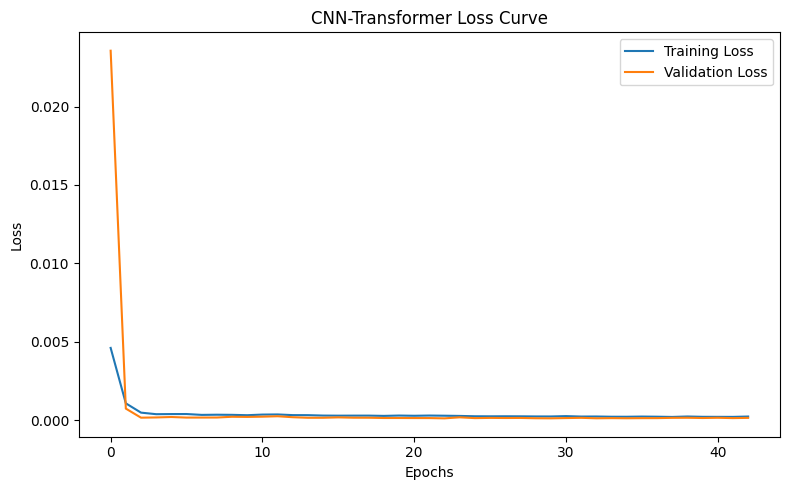

In [45]:

# CNN-TRANSFORMER LOSS CURVE


plt.figure(figsize=(8, 5))

plt.plot(
    history_transformer.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_transformer.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("CNN-Transformer Loss Curve")

plt.legend()

plt.tight_layout()

plt.show()

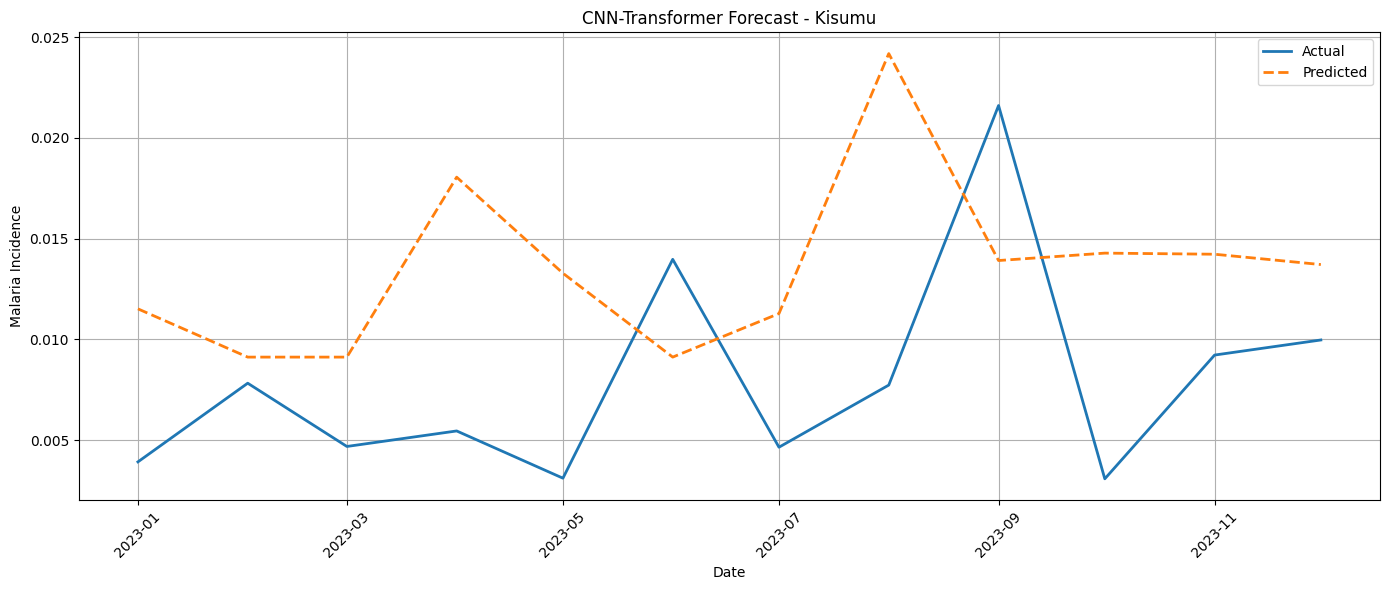

In [46]:

# CNN-TRANSFORMER TIME SERIES


county_name = "Kisumu"

county_data = test_df[
    test_df["county"] == county_name
].copy()

county_data = county_data.sort_values("date")

actual = county_data["incidence_per_1000"].values

predicted = transformer_pred[county_data.index]

dates = county_data["date"]

plt.figure(figsize=(14, 6))

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates,
    predicted,
    linestyle="--",
    label="Predicted",
    linewidth=2
)

plt.xlabel("Date")

plt.ylabel("Malaria Incidence")

plt.title(f"CNN-Transformer Forecast - {county_name}")

plt.legend()

plt.grid(True)

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

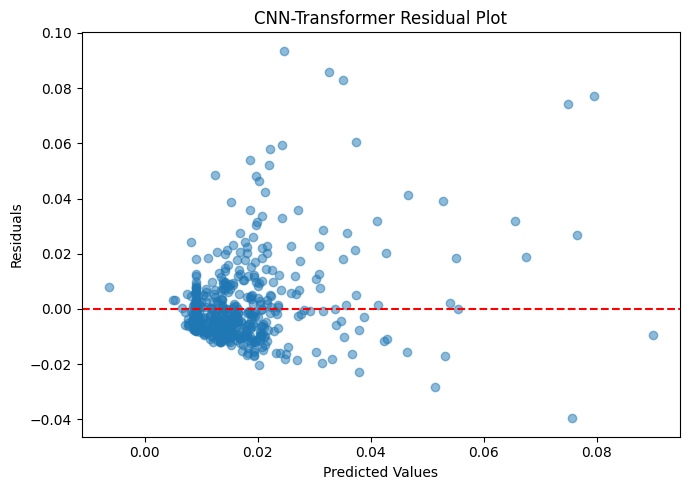

In [47]:

# CNN-TRANSFORMER RESIDUAL PLOT


residuals = yte - transformer_pred

plt.figure(figsize=(7, 5))

plt.scatter(
    transformer_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Values")

plt.ylabel("Residuals")

plt.title("CNN-Transformer Residual Plot")

plt.tight_layout()

plt.show()

## MODEL COMPARISON TABLE

In [48]:

# FINAL MODEL COMPARISON TABLE


results = pd.DataFrame({

    "Model": [
        "LSTM",
        "CNN-LSTM",
        "CNN-GRU",
        "CNN-Transformer"
    ],

    "RMSE": [
        lstm_rmse,
        cnn_lstm_rmse,
        cnn_gru_rmse,
        transformer_rmse
    ],

    "MAE": [
        lstm_mae,
        cnn_lstm_mae,
        cnn_gru_mae,
        transformer_mae
    ],

    "R2": [
        lstm_r2,
        cnn_lstm_r2,
        cnn_gru_r2,
        transformer_r2
    ]
})

print(results)


             Model      RMSE       MAE        R2
0             LSTM  0.010620  0.006413  0.720414
1         CNN-LSTM  0.008764  0.005248  0.809611
2          CNN-GRU  0.010146  0.006092  0.744812
3  CNN-Transformer  0.014470  0.009105  0.480956


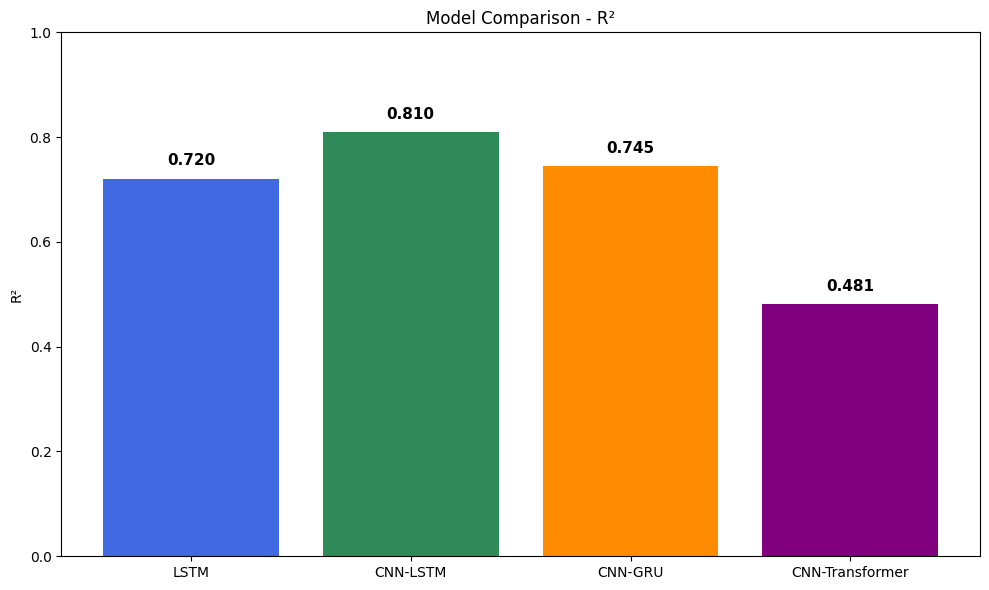

In [49]:
import matplotlib.pyplot as plt

# MODEL COLORS

model_colors = {
    "LSTM": "royalblue",
    "CNN-LSTM": "seagreen",
    "CNN-GRU": "darkorange",
    "CNN-Transformer": "purple"
}

# R2 COMPARISON

plt.figure(figsize=(10, 6))

colors = [
    model_colors[m]
    for m in results["Model"]
]

bars = plt.bar(
    results["Model"],
    results["R2"],
    color=colors
)

# ADD R² VALUES ON TOP OF BARS

for bar, value in zip(bars, results["R2"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel("R²")

plt.title("Model Comparison - R²")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "model_comparison_R2.png",
    bbox_inches='tight'
)

plt.show()

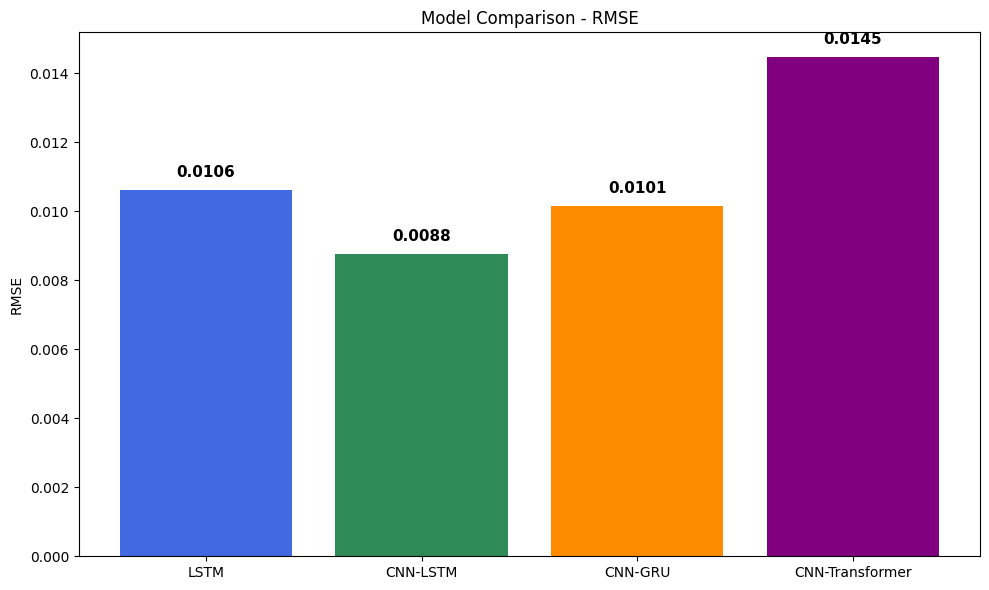

In [50]:

import matplotlib.pyplot as plt

# RMSE COMPARISON

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["RMSE"],
    color=colors
)

# ADD RMSE VALUES ON TOP OF BARS

for bar, value in zip(bars, results["RMSE"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel("RMSE")

plt.title("Model Comparison - RMSE")

plt.tight_layout()

plt.savefig(
    "model_comparison_RMSE.png",
    bbox_inches='tight'
)

plt.show()

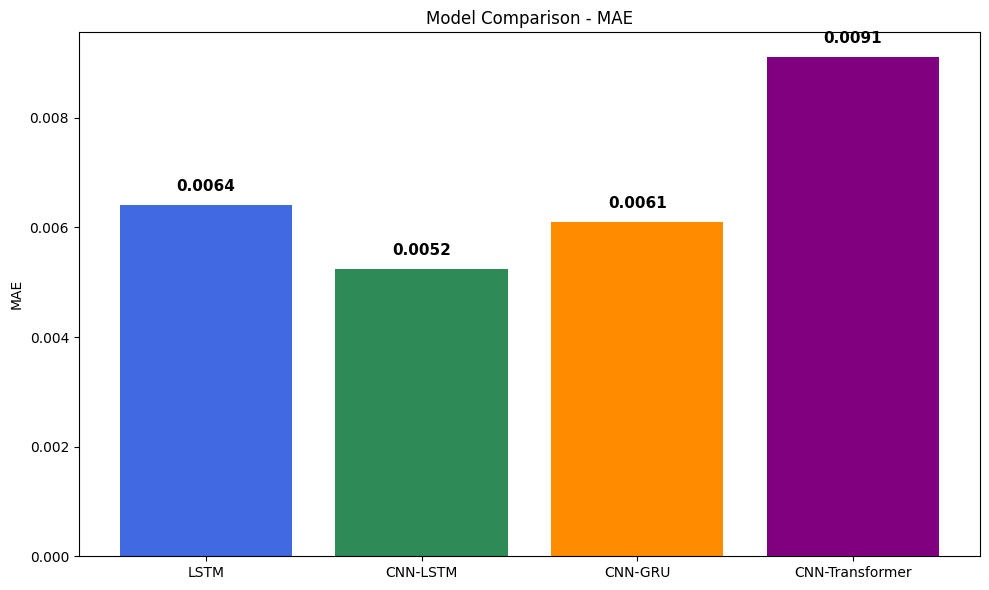

In [51]:

import matplotlib.pyplot as plt

# MAE COMPARISON

plt.figure(figsize=(10, 6))

bars = plt.bar(
    results["Model"],
    results["MAE"],
    color=colors
)

# ADD MAE VALUES ON TOP OF BARS

for bar, value in zip(bars, results["MAE"]):

    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0002,
        f"{value:.4f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.ylabel("MAE")

plt.title("Model Comparison - MAE")

plt.tight_layout()

plt.savefig(
    "model_comparison_MAE.png",
    bbox_inches='tight'
)

plt.show()

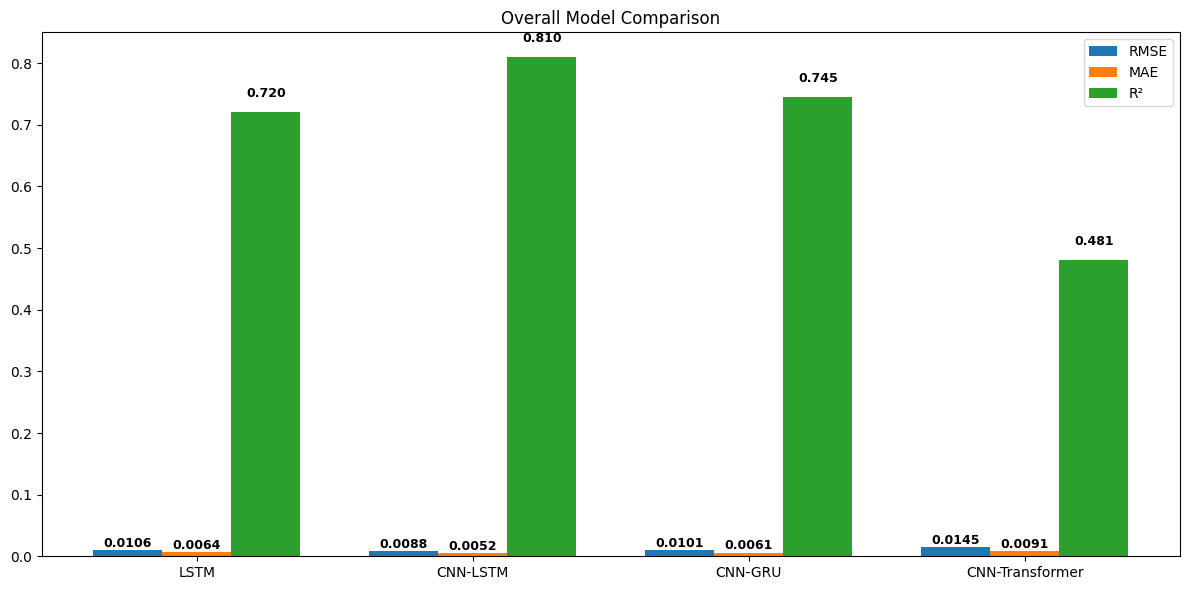

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# COMBINED METRICS

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results))

w = 0.25

# BARS

bars1 = ax.bar(
    x - w,
    results["RMSE"],
    width=w,
    label="RMSE"
)

bars2 = ax.bar(
    x,
    results["MAE"],
    width=w,
    label="MAE"
)

bars3 = ax.bar(
    x + w,
    results["R2"],
    width=w,
    label="R²"
)

# ADD VALUES ON TOP OF RMSE BARS

for bar, value in zip(bars1, results["RMSE"]):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0003,
        f"{value:.4f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# ADD VALUES ON TOP OF MAE BARS

for bar, value in zip(bars2, results["MAE"]):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0002,
        f"{value:.4f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

# ADD VALUES ON TOP OF R² BARS

for bar, value in zip(bars3, results["R2"]):

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{value:.3f}",
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold'
    )

ax.set_xticks(x)

ax.set_xticklabels(results["Model"])

ax.set_title("Overall Model Comparison")

ax.legend()

plt.tight_layout()

plt.savefig(
    "overall_model_comparison.png",
    bbox_inches='tight'
)

plt.show()

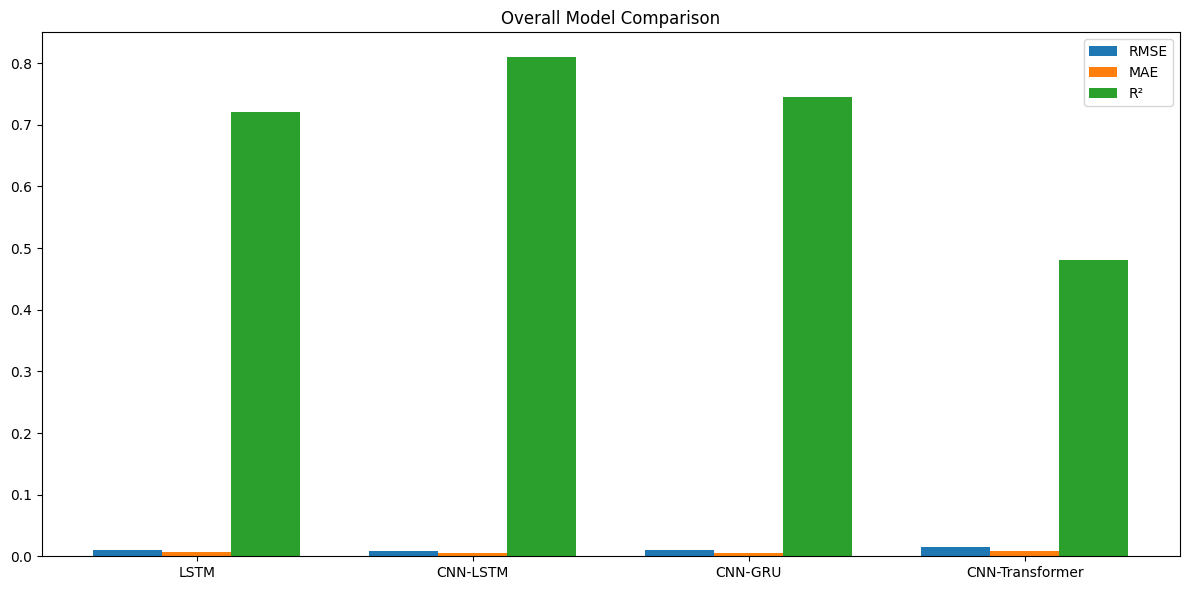

In [53]:

# COMBINED METRICS


fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(results))

w = 0.25

ax.bar(
    x - w,
    results["RMSE"],
    width=w,
    label="RMSE"
)

ax.bar(
    x,
    results["MAE"],
    width=w,
    label="MAE"
)

ax.bar(
    x + w,
    results["R2"],
    width=w,
    label="R²"
)

ax.set_xticks(x)

ax.set_xticklabels(results["Model"])

ax.set_title("Overall Model Comparison")

ax.legend()

plt.tight_layout()

plt.show()

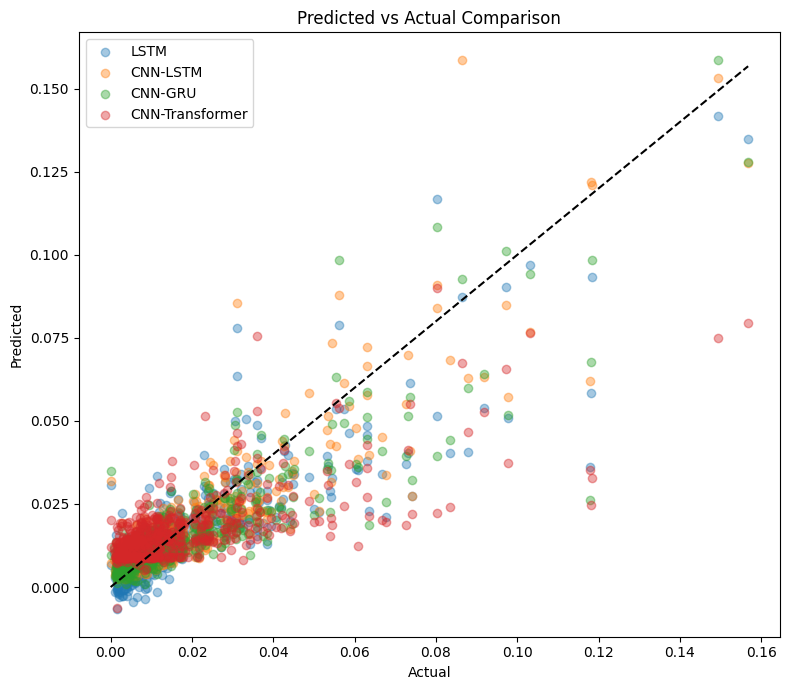

In [54]:
#
# PREDICTION COMPARISON


plt.figure(figsize=(8, 7))

plt.scatter(
    yte,
    lstm_pred,
    alpha=0.4,
    label="LSTM"
)

plt.scatter(
    yte,
    cnn_lstm_pred,
    alpha=0.4,
    label="CNN-LSTM"
)

plt.scatter(
    yte,
    cnn_gru_pred,
    alpha=0.4,
    label="CNN-GRU"
)

plt.scatter(
    yte,
    transformer_pred,
    alpha=0.4,
    label="CNN-Transformer"
)

mn = yte.min()

mx = yte.max()

plt.plot(
    [mn, mx],
    [mn, mx],
    "k--"
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Predicted vs Actual Comparison")

plt.legend()

plt.tight_layout()
plt.savefig("Predicted vs Actual.png", bbox_inches='tight')
plt.show()


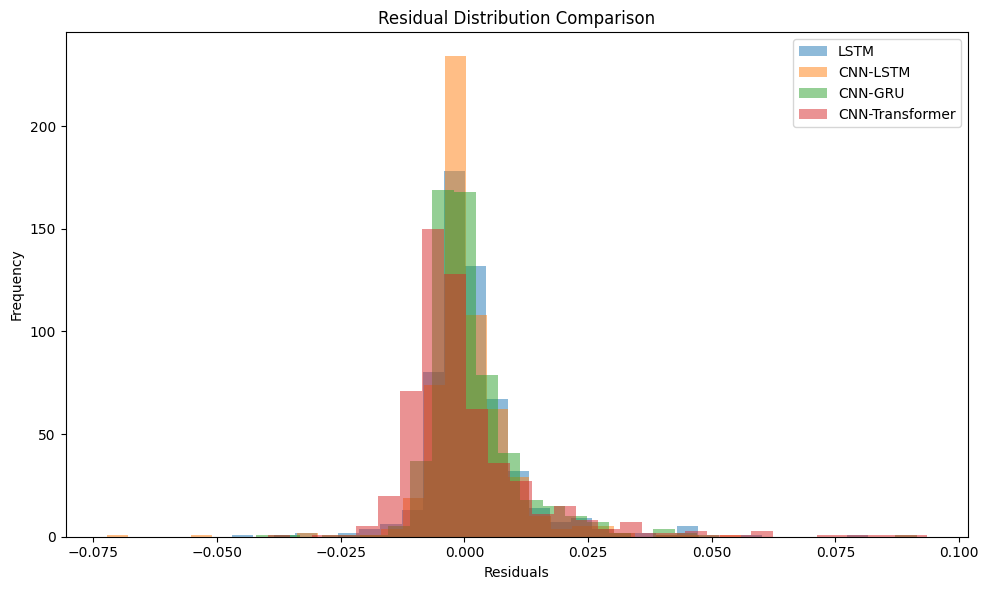

In [55]:

# RESIDUAL DISTRIBUTION


plt.figure(figsize=(10, 6))

plt.hist(
    yte - lstm_pred,
    bins=30,
    alpha=0.5,
    label="LSTM"
)

plt.hist(
    yte - cnn_lstm_pred,
    bins=30,
    alpha=0.5,
    label="CNN-LSTM"
)

plt.hist(
    yte - cnn_gru_pred,
    bins=30,
    alpha=0.5,
    label="CNN-GRU"
)

plt.hist(
    yte - transformer_pred,
    bins=30,
    alpha=0.5,
    label="CNN-Transformer"
)

plt.xlabel("Residuals")

plt.ylabel("Frequency")

plt.title("Residual Distribution Comparison")

plt.legend()

plt.tight_layout()

plt.savefig("Residual Distribution.png", bbox_inches='tight')
plt.show()


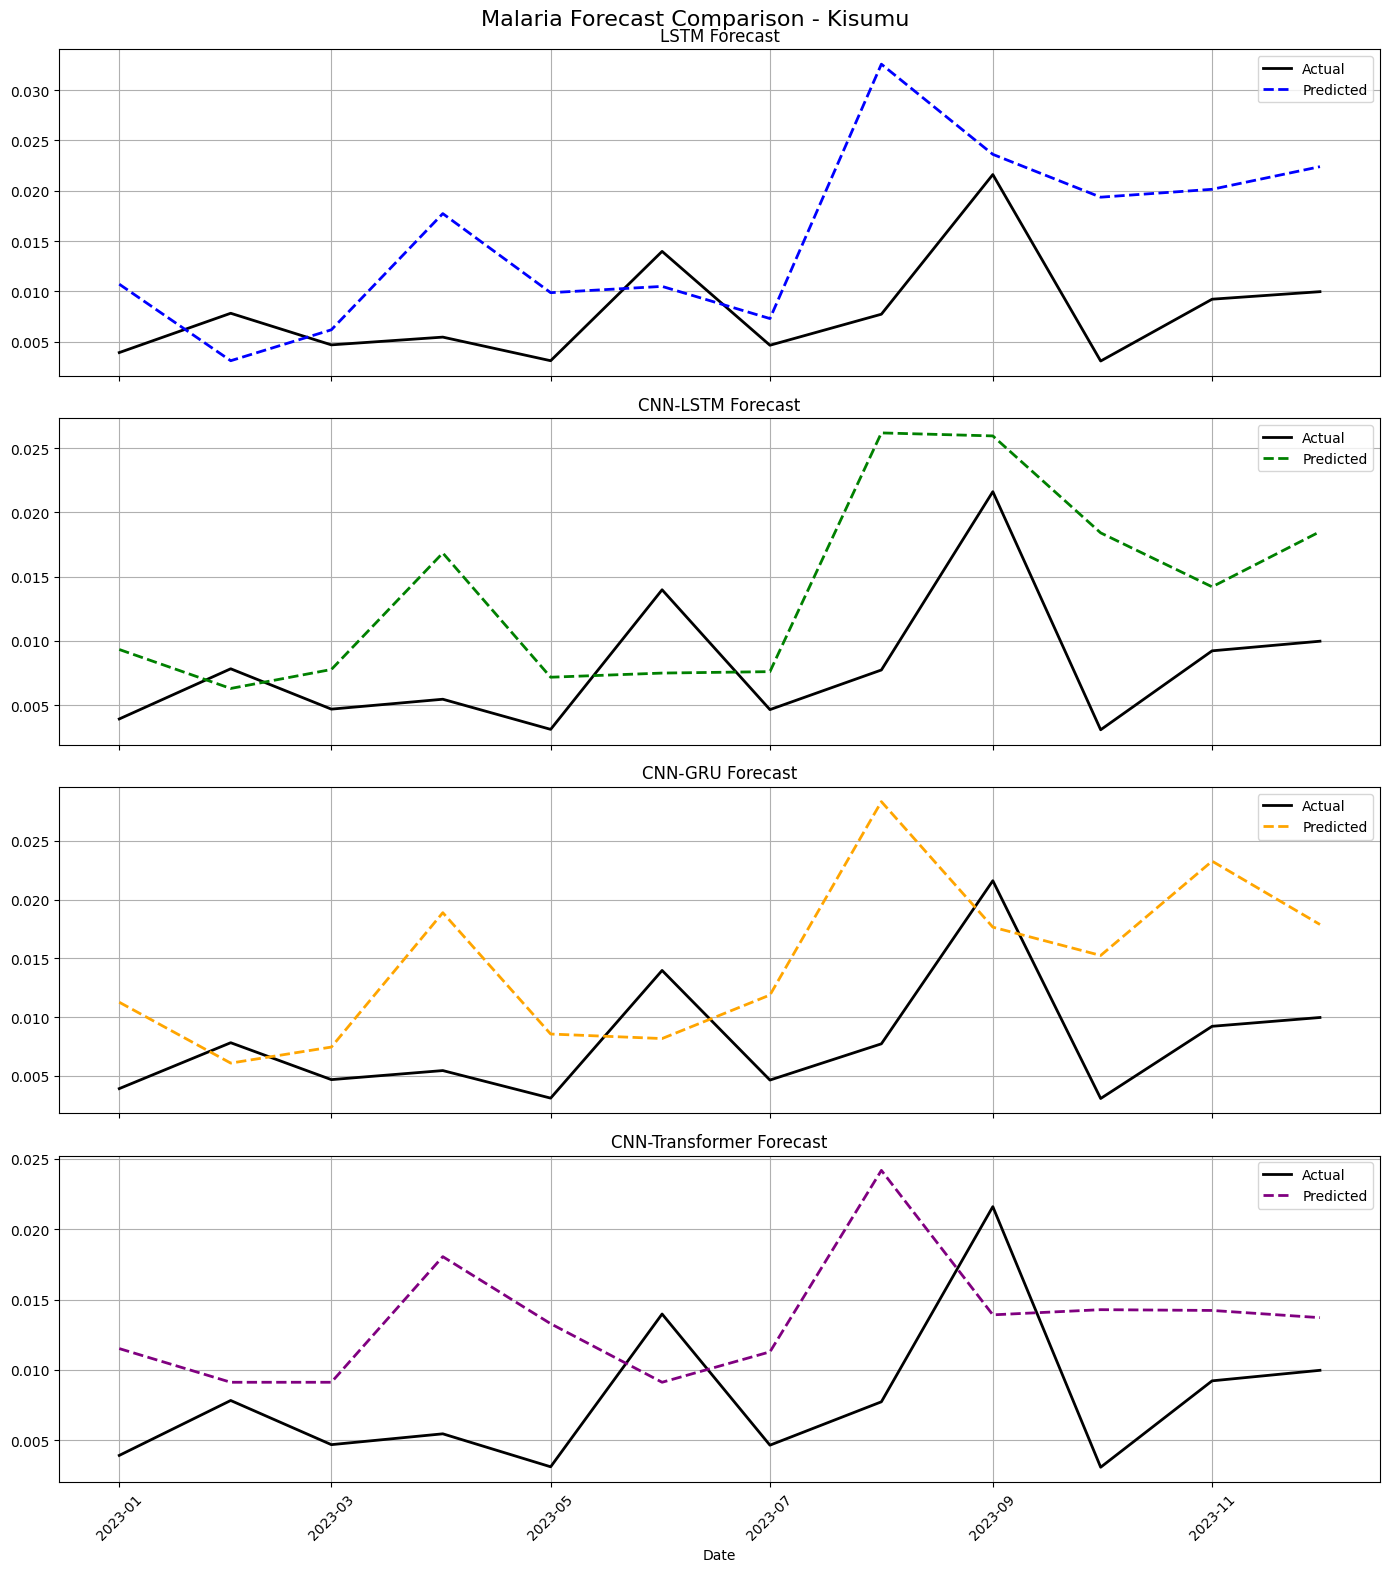

In [56]:

# MULTI-MODEL TIME SERIES COMPARISON


county_name = "Kisumu"

# Select county
county_data = test_df[
    test_df["county"] == county_name
].copy()

county_data = county_data.sort_values("date")

dates = county_data["date"]

actual = county_data["incidence_per_1000"].values

# Predictions
lstm_series = lstm_pred[county_data.index]

cnn_lstm_series = cnn_lstm_pred[county_data.index]

cnn_gru_series = cnn_gru_pred[county_data.index]

transformer_series = transformer_pred[county_data.index]


# CREATE SUBPLOTS


fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 16),
    sharex=True
)


# LSTM


axes[0].plot(
    dates,
    actual,
    color="black",
    linewidth=2,
    label="Actual"
)

axes[0].plot(
    dates,
    lstm_series,
    color="blue",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

axes[0].set_title("LSTM Forecast")

axes[0].legend()

axes[0].grid(True)


# CNN-LSTM


axes[1].plot(
    dates,
    actual,
    color="black",
    linewidth=2,
    label="Actual"
)

axes[1].plot(
    dates,
    cnn_lstm_series,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

axes[1].set_title("CNN-LSTM Forecast")

axes[1].legend()

axes[1].grid(True)


# CNN-GRU


axes[2].plot(
    dates,
    actual,
    color="black",
    linewidth=2,
    label="Actual"
)

axes[2].plot(
    dates,
    cnn_gru_series,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

axes[2].set_title("CNN-GRU Forecast")

axes[2].legend()

axes[2].grid(True)

#
# CNN-TRANSFORMER


axes[3].plot(
    dates,
    actual,
    color="black",
    linewidth=2,
    label="Actual"
)

axes[3].plot(
    dates,
    transformer_series,
    color="purple",
    linestyle="--",
    linewidth=2,
    label="Predicted"
)

axes[3].set_title("CNN-Transformer Forecast")

axes[3].legend()

axes[3].grid(True)


# FINAL SETTINGS


plt.xlabel("Date")

plt.xticks(rotation=45)

plt.suptitle(
    f"Malaria Forecast Comparison - {county_name}",
    fontsize=16
)

plt.tight_layout()
plt.savefig("Malaria Forecast Comparison.png", bbox_inches='tight')
plt.show()



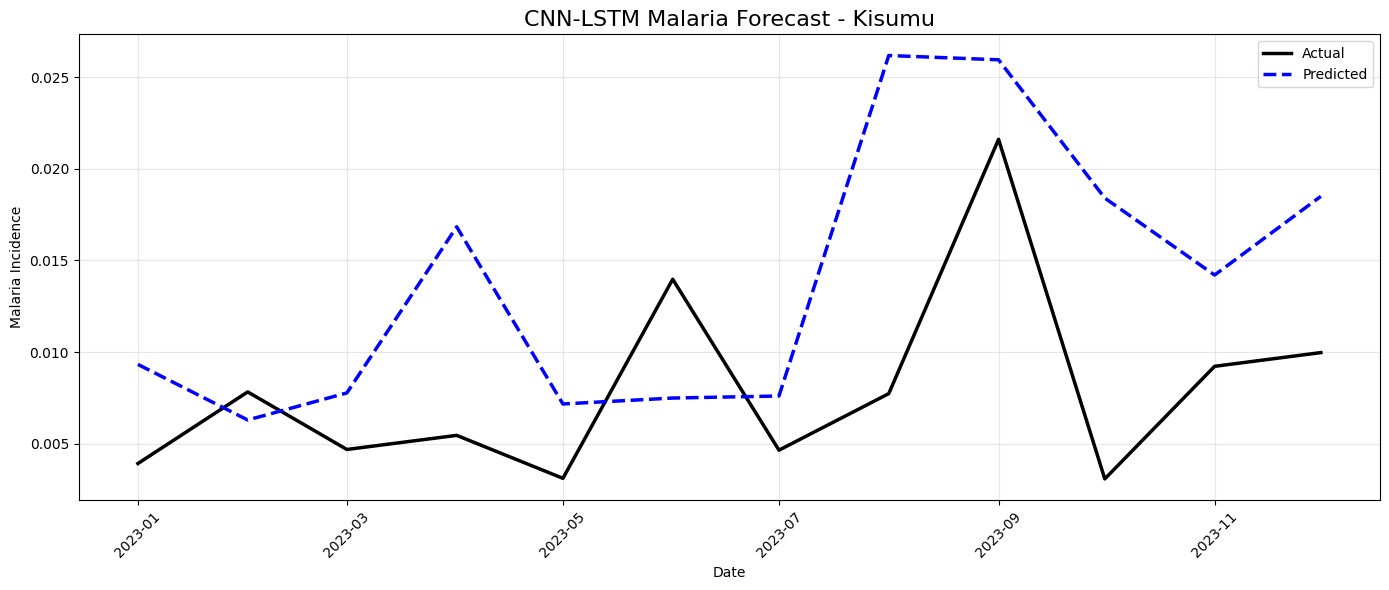

In [57]:

# FORECAST PLOT


county_name = "Kisumu"

# Select one county
county_data = test_df[
    test_df["county"] == county_name
].copy()

# Sort dates
county_data = county_data.sort_values("date")

# Actual values
actual = county_data["incidence_per_1000"].values

# CNN-LSTM predictions
predicted = cnn_lstm_pred[county_data.index]

# Dates
dates = county_data["date"]


# PLOTTING THE ACTUAL AND PREDICTED LINE


plt.figure(figsize=(14, 6))

# Actual line
plt.plot(
    dates,
    actual,
    color="black",
    linewidth=2.5,
    label="Actual"
)

# Predicted line
plt.plot(
    dates,
    predicted,
    color="blue",
    linestyle="--",
    linewidth=2.5,
    label="Predicted"
)



plt.title(
    f"CNN-LSTM Malaria Forecast - {county_name}",
    fontsize=16
)

plt.xlabel("Date")

plt.ylabel("Malaria Incidence")

plt.grid(True, alpha=0.3)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


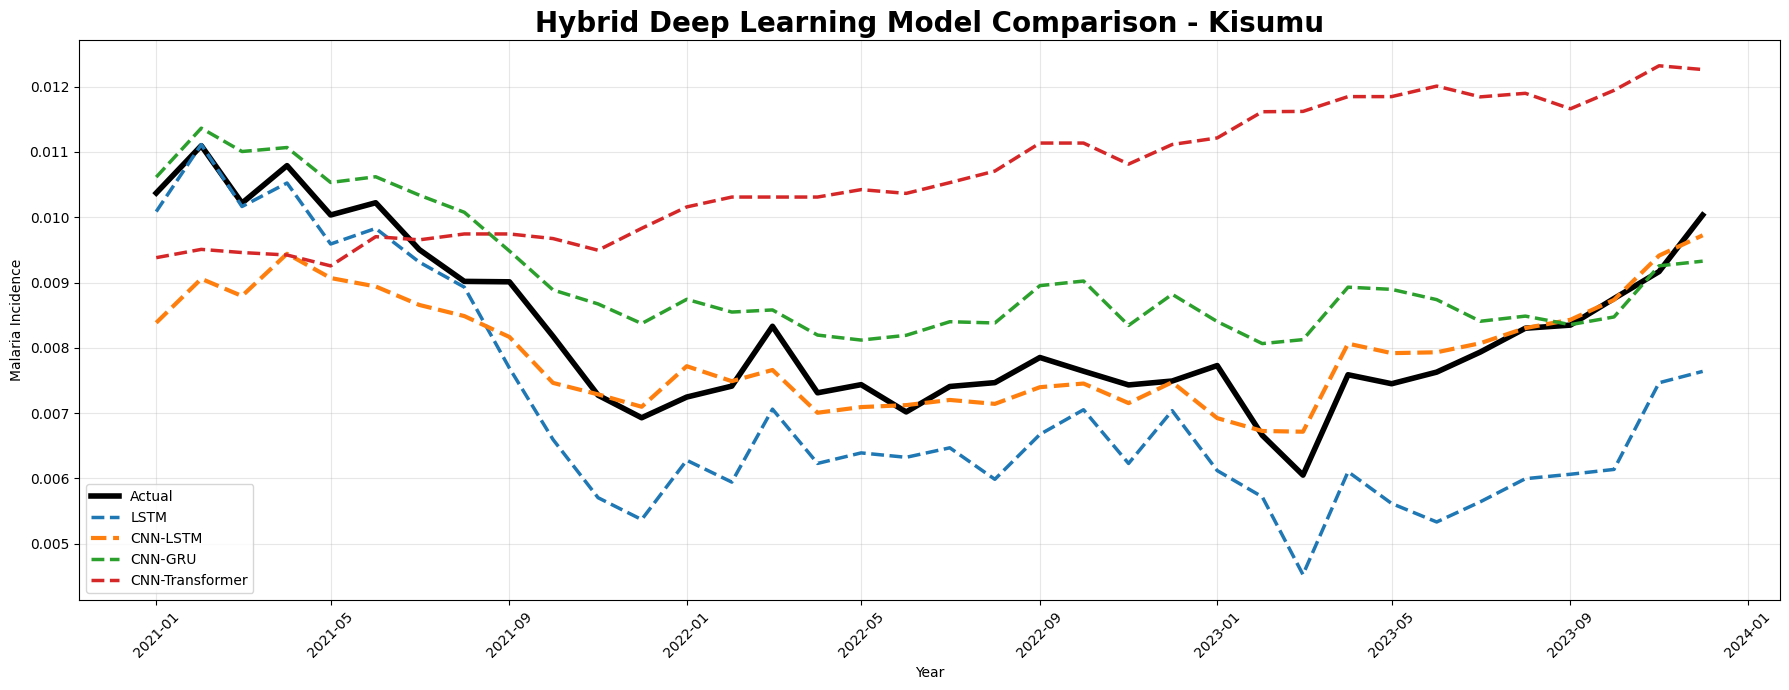

In [58]:

# FINAL MODEL COMPARISON PLOT


import pandas as pd
import matplotlib.pyplot as plt


county_name = "Kisumu"


# FILTER DATA


county_data = df[
    (df["county"] == county_name) &
    (df["date"] >= "2021-01-01")
].copy()

county_data = county_data.sort_values("date")

# FEATURES

X_county = sx.transform(
    county_data[FEATS]
)

X_county_dl = X_county.reshape(
    X_county.shape[0],
    X_county.shape[1],
    1
)


# PREDICTIONS


lstm_pred_plot = (
    lstm_model.predict(X_county_dl)
    .flatten()
)

cnn_lstm_pred_plot = (
    cnn_lstm.predict(X_county_dl)
    .flatten()
)

cnn_gru_pred_plot = (
    cnn_gru.predict(X_county_dl)
    .flatten()
)

transformer_pred_plot = (
    cnn_transformer.predict(X_county_dl)
    .flatten()
)


# ACTUAL VALUES


actual = county_data[
    "incidence_per_1000"
].values

dates = pd.to_datetime(
    county_data["date"]
)


#  SMOOTHING


actual_smooth = (
    pd.Series(actual)
    .interpolate(method="linear")
    .rolling(12, min_periods=1, center=True)
    .mean()
)

lstm_smooth = (
    pd.Series(lstm_pred_plot)
    .interpolate(method="linear")
    .rolling(12, min_periods=1, center=True)
    .mean()
)

cnn_lstm_smooth = (
    pd.Series(cnn_lstm_pred_plot)
    .interpolate(method="linear")
    .rolling(12, min_periods=1, center=True)
    .mean()
)

cnn_gru_smooth = (
    pd.Series(cnn_gru_pred_plot)
    .interpolate(method="linear")
    .rolling(12, min_periods=1, center=True)
    .mean()
)

transformer_smooth = (
    pd.Series(transformer_pred_plot)
    .interpolate(method="linear")
    .rolling(12, min_periods=1, center=True)
    .mean()
)


# PLOTTING ALL THE MODELS

plt.figure(figsize=(18, 7))

# Actual
plt.plot(
    dates,
    actual_smooth,
    color="black",
    linewidth=4,
    label="Actual"
)

# LSTM
plt.plot(
    dates,
    lstm_smooth,
    linewidth=2.5,
    linestyle="--",
    label="LSTM"
)

# CNN-LSTM
plt.plot(
    dates,
    cnn_lstm_smooth,
    linewidth=3,
    linestyle="--",
    label="CNN-LSTM"
)

# CNN-GRU
plt.plot(
    dates,
    cnn_gru_smooth,
    linewidth=2.5,
    linestyle="--",
    label="CNN-GRU"
)

# CNN-Transformer
plt.plot(
    dates,
    transformer_smooth,
    linewidth=2.5,
    linestyle="--",
    label="CNN-Transformer"
)

# STYLING


plt.title(
    "Hybrid Deep Learning Model Comparison - Kisumu",
    fontsize=20,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Malaria Incidence")

plt.grid(True, alpha=0.3)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("Hybrid Deep Learning Model Comparison - Kisumu.png", bbox_inches='tight')
plt.show()


In [59]:


import shap
import numpy as np


background = Xtr_dl[
    np.random.choice(
        Xtr_dl.shape[0],
        50,
        replace=False
    )
]


# TEST SAMPLE


test_sample = Xte_dl[:50]


# PREDICTION FUNCTION

def model_predict(x):

    x = x.reshape(
        x.shape[0],
        x.shape[1],
        1
    )

    return cnn_lstm.predict(x)


# RESHAPE


background_2d = background.reshape(
    background.shape[0],
    background.shape[1]
)

test_2d = test_sample.reshape(
    test_sample.shape[0],
    test_sample.shape[1]
)

# KERNEL EXPLAINER


explainer = shap.KernelExplainer(
    model_predict,
    background_2d
)

# COMPUTE SHAP VALUES


shap_values = explainer.shap_values(
    test_2d
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


  0%|                                                    | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


  2%|▉                                           | 1/50 [00:09<07:49,  9.57s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


...

 96%|█████████████████████████████████████████▎ | 48/50 [07:34<00:18,  9.46s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


 98%|██████████████████████████████████████████▏| 49/50 [07:44<00:09,  9.45s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
3285/3285 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step


100%|███████████████████████████████████████████| 50/50 [07:53<00:00,  9.47s/it]


Original SHAP shape:
(50, 27, 1)
Fixed SHAP shape:
(50, 27)
Feature count:
27


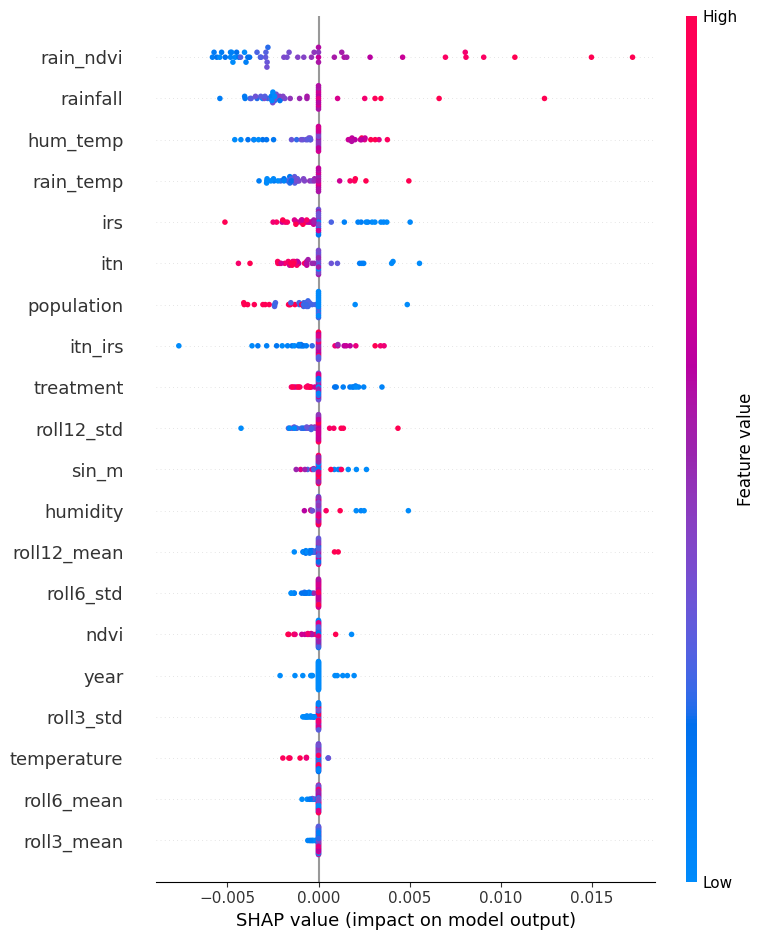

<Figure size 640x480 with 0 Axes>

In [60]:


# FIX SHAP OUTPUT DIMENSIONS


shap_array = np.array(shap_values)

print("Original SHAP shape:")
print(shap_array.shape)


# HANDLE EXTRA DIMENSIONS


if len(shap_array.shape) == 3:

    shap_array = shap_array[:, :, 0]

elif len(shap_array.shape) == 4:

    shap_array = shap_array[0, :, :, 0]

# CHECK FINAL SHAPE


print("Fixed SHAP shape:")
print(shap_array.shape)

print("Feature count:")
print(len(FEATS))


# SUMMARY PLOT



shap.summary_plot(
    shap_array,
    test_2d,
    feature_names=FEATS
)
plt.savefig("ShapValues.png", bbox_inches='tight')

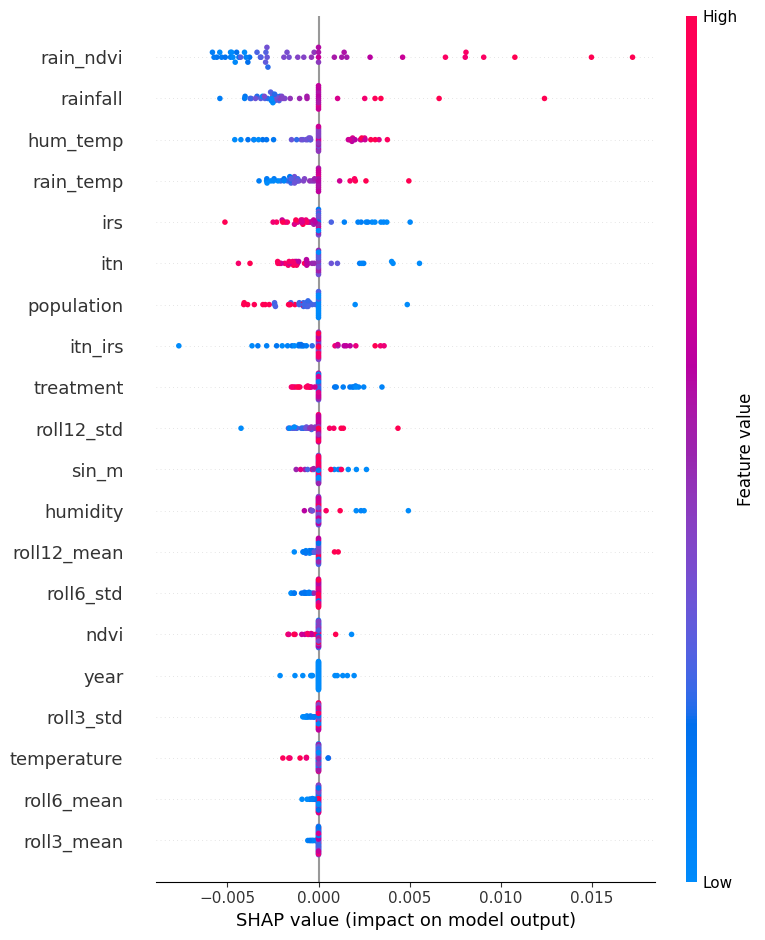

In [67]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 8))


shap.summary_plot(
    shap_array, 
    test_2d, 
    feature_names=FEATS, 
    show=False  
)


plt.savefig("ShapValues.png", bbox_inches='tight', dpi=300)


plt.show()